# 03 — Baseline y regresion Poisson

### Objetivo
Establecer lineas base y entrenar una regresion Poisson como primer modelo real.

### Modelos implentados
- **Baseline 1**: predice la media global (un solo numero para todas las celdas).
- **Baseline 2**: predice la media por (distrito, turno, semana_del_anio).
- **Poisson Regression**: regresion lineal con link logaritmico. log(y) = X·beta. Es "lineal" en las features, no en el target. La salida es y = exp(X·beta).

### Poisson lineal como baseline
- Es lo mas simple que captura la relacion features-target con perdida Poisson.
- Cualquier modelo mas complejo (XGBoost, LightGBM) debe superarlo.

### Metricas
- **RMSE**: raiz del error cuadratico medio. Castigo igual a todos los errores.
- **MAE**: error absoluto medio. Menos sensible a outliers que RMSE.
- **Poisson Deviance**: metrica natural para conteos. Penaliza mas subestimar que sobreestimar (asimétrico).
- **McFadden R²**: 1 - deviance/deviance_nulo. Como R² pero con deviance Poisson.

### Split
- Train: semanas 1-62 (2025-W01 a 2026-W14).
- Test: semanas 63-74 (2026-W15 a 2026-W22, ultimas 12 semanas).

In [1]:
# Carga y split temporal
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Data")
FIG_DIR = Path("/Users/guillermo/Downloads/TA_IA_Aplicada/Modelado/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_DIR / "df_features.csv")

SEMANA_HOLDOUT_INICIO = 63
df_train = df[df["semana_global"] < SEMANA_HOLDOUT_INICIO].copy()
df_test  = df[df["semana_global"] >= SEMANA_HOLDOUT_INICIO].copy()
y_train = df_train["count_robos"].values
y_test  = df_test["count_robos"].values
print(f"Train: {df_train.shape[0]} | Test: {df_test.shape[0]}")

Train: 10664 | Test: 2064


### Funciones de metricas

In [2]:
# Definicion de metricas de evaluacion
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def poisson_deviance(y_true, y_pred, eps=1e-10):
    # D = 2 * sum(y*log(y/y_pred) - (y - y_pred))
    # Cuando y=0, el termino y*log(y/y_pred) -> 0 por convencion, pero log(0)=-inf y 0*-inf=NaN
    # Por eso usamos np.where: si y==0, ese termino es 0
    y_pred = np.clip(y_pred, eps, None)
    y_true = np.asarray(y_true, dtype=float)
    term1 = np.where(y_true > 0, y_true * np.log(y_true / y_pred), 0.0)
    return 2 * np.sum(term1 - (y_true - y_pred))

def print_metrics(name, y_true, y_pred):
    r = rmse(y_true, y_pred)
    m = mae(y_true, y_pred)
    d = poisson_deviance(y_true, y_pred)
    r2 = 1 - d / poisson_deviance(y_true, np.full_like(y_true, y_true.mean(), dtype=float))
    print(f"  {name:32s} | RMSE={r:6.2f} | MAE={m:6.2f} | PoissonDev={d:10.1f} | R2={r2:6.3f}")
    return {"modelo": name, "rmse": r, "mae": m, "poisson_dev": d, "mcfadden_r2": r2}

### Baseline 1: media global

In [3]:
# Predice la media global de count_robos para todas las celdas
resultados = []
media_global = df_train["count_robos"].mean()
y_pred_b1 = np.full(len(y_test), media_global)
resultados.append(print_metrics("Baseline 1: media global", y_test, y_pred_b1))

  Baseline 1: media global         | RMSE= 12.15 | MAE=  9.35 | PoissonDev=   24136.9 | R2=-0.000


### Baseline 2: media historica por (distrito, turno, semana_del_anio)

In [4]:
# Reconstruir turno_hecho desde las columnas OHE
turno_cols = [c for c in df_train.columns if c.startswith("turno_")]
df_train["turno_hecho"] = df_train[turno_cols].idxmax(axis=1).str.replace("turno_", "")
df_test["turno_hecho"]  = df_test[turno_cols].idxmax(axis=1).str.replace("turno_", "")

In [5]:
# Media por (distrito, turno, semana_del_anio) calculada SOLO con train
media_b2_train = (df_train
    .groupby(["distrito_hecho", "turno_hecho", "semana_del_año"])["count_robos"]
    .mean()
    .reset_index()
    .rename(columns={"count_robos": "media_b2"})
)

df_test_b2 = df_test.merge(media_b2_train,
    on=["distrito_hecho", "turno_hecho", "semana_del_año"], how="left")
df_test_b2["media_b2"] = df_test_b2["media_b2"].fillna(media_global)

y_pred_b2 = df_test_b2["media_b2"].values
resultados.append(print_metrics("Baseline 2: media historica (D,T,sem)", y_test, y_pred_b2))

  Baseline 2: media historica (D,T,sem) | RMSE=  8.61 | MAE=  5.25 | PoissonDev=   17419.3 | R2= 0.278


### Poisson regression lineal

In [6]:
# Definir features: numericas + OHE turno/subtipo
feature_cols_num = [
    "semana_del_año_sin", "semana_del_año_cos", "mes_sin", "mes_cos",
    "semana_con_festivo",
    "count_lag_1w", "count_lag_2w", "count_lag_4w", "count_lag_8w", "count_lag_52w",
    "rolling_mean_4w", "rolling_mean_8w", "rolling_mean_12w",
    "rolling_std_4w", "rolling_std_8w",
    "media_historica",
    "distrito_id",
]
feature_cols_ohe = [c for c in df.columns if c.startswith("turno_") or c.startswith("subtipo_")]
feature_cols = feature_cols_num + feature_cols_ohe
print(f"Features: {len(feature_cols)}")

Features: 22


In [7]:
# Estandarizar con StandardScaler fit solo en train (evita leakage)
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler

X_train = df_train[feature_cols].values
X_test  = df_test[feature_cols].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [8]:
# Entrenar PoissonRegressor y predecir en test
poisson = PoissonRegressor(alpha=0.01, max_iter=1000)
poisson.fit(X_train_s, y_train)
y_pred_poisson_test = poisson.predict(X_test_s)
resultados.append(print_metrics("Poisson Regression (test)", y_test, y_pred_poisson_test))

  Poisson Regression (test)        | RMSE=  6.90 | MAE=  5.02 | PoissonDev=    8446.6 | R2= 0.650


### Visualizacion: Real vs Predicho

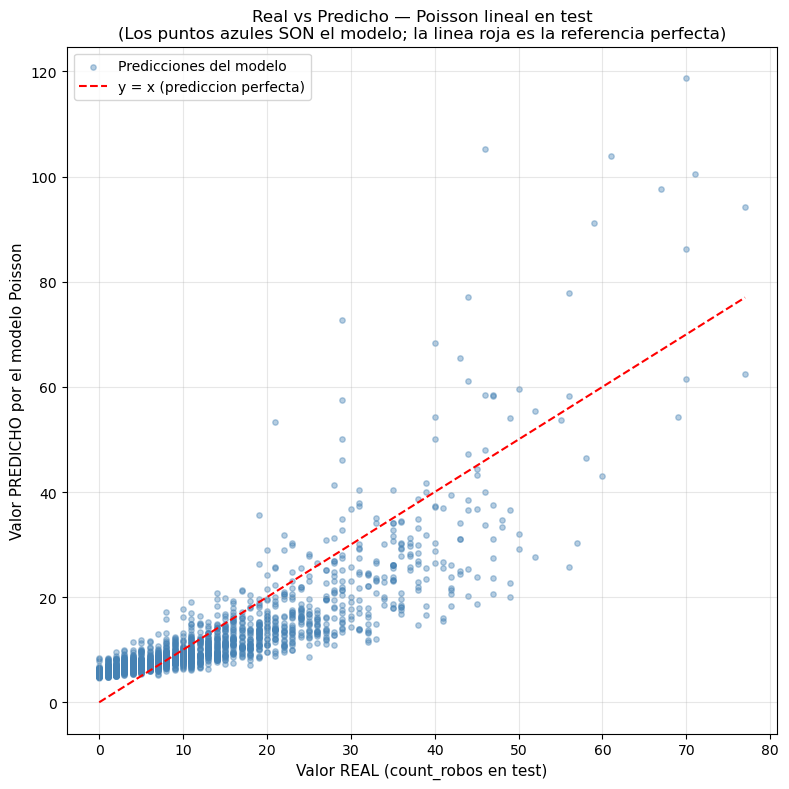

In [9]:
# Scatter plot: cada punto es una prediccion del modelo
# - Eje X = valor real (count_robos en test)
# - Eje Y = valor predicho por el modelo Poisson lineal
# - LINEA ROJA = diagonal y=x (prediccion PERFECTA, NO es el modelo)
# - Si el modelo fuera perfecto, todos los puntos caerían sobre la linea roja
# - Puntos azules = las predicciones reales del modelo (eso es el modelo)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_poisson_test, alpha=0.4, s=15, color="steelblue", label="Predicciones del modelo")
ax.plot([0, y_test.max()], [0, y_test.max()], "r--", lw=1.5, label="y = x (prediccion perfecta)")
ax.set_xlabel("Valor REAL (count_robos en test)", fontsize=11)
ax.set_ylabel("Valor PREDICHO por el modelo Poisson", fontsize=11)
ax.set_title("Real vs Predicho — Poisson lineal en test\n(Los puntos azules SON el modelo; la linea roja es la referencia perfecta)", fontsize=12)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "poisson_real_vs_predicho.png", dpi=120, bbox_inches="tight")
plt.show()

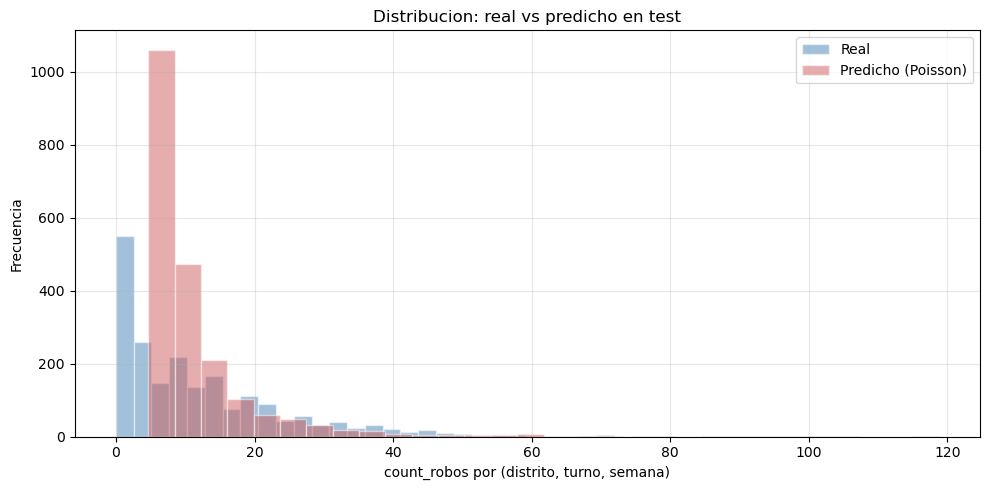

In [10]:
# Distribucion comparada: real vs predicho
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(y_test, bins=30, alpha=0.5, label="Real", color="steelblue", edgecolor="white")
ax.hist(y_pred_poisson_test, bins=30, alpha=0.5, label="Predicho (Poisson)", color="indianred", edgecolor="white")
ax.set_xlabel("count_robos por (distrito, turno, semana)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribucion: real vs predicho en test")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "poisson_distribucion.png", dpi=120, bbox_inches="tight")
plt.show()

### Coeficientes del modelo

In [11]:
# Coeficientes ordenados por magnitud: que feature aporta mas
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": poisson.coef_,
}).sort_values("coef", key=abs, ascending=False)
print("Top 15 coeficientes (valor absoluto):")
print(coef_df.head(15).to_string(index=False))

Top 15 coeficientes (valor absoluto):
           feature      coef
   rolling_mean_4w  0.198814
  rolling_mean_12w  0.167587
      count_lag_1w  0.115870
semana_del_año_sin -0.089447
    rolling_std_8w  0.076623
           mes_cos -0.048316
           mes_sin  0.043055
       distrito_id  0.038612
    rolling_std_4w  0.037575
      count_lag_4w -0.032853
semana_con_festivo -0.031325
semana_del_año_cos  0.029827
   rolling_mean_8w -0.024888
      count_lag_2w  0.019457
      count_lag_8w  0.015713


In [12]:
# Guardar tabla de resultados
df_resultados = pd.DataFrame(resultados)
OUT_CSV = DATA_DIR / "resultados_baseline.csv"
df_resultados.to_csv(OUT_CSV, index=False)
print(f"Guardado: {OUT_CSV}")

Guardado: /Users/guillermo/Downloads/TA_IA_Aplicada/Data/resultados_baseline.csv


### Resumen
- Baseline 1 (media global): RMSE alto porque ignora toda la estructura.
- Baseline 2 (media D,T,sem): captura la estacionalidad, mejora mucho.
- Poisson lineal: anade el valor de los lags y rolling, mejor aun.

**Conclusión**: el Poisson lineal ya muestra que la estructura del problema es aprovechable. Los modelos de gradient boosting (XGBoost, LightGBM) del notebook 04 deberían superarlo. Siguiente paso: `04_xgb_lgbm.ipynb`.